# 12 - Final Held-Out Peak-Hour Test Evaluation

This notebook performs the final evaluation of daily peak-hour prediction. The
model configuration, features, quality policy, and evaluation metrics were fixed
before the held-out test period was examined.

The final test period is used once for reporting. It is not used for feature
selection, model selection, threshold adjustment, or hyperparameter tuning.

## Final Evaluation Rules

- Train on the combined training and validation periods.
- Evaluate on the untouched chronological test period.
- Include complete days with changing readings, including days containing some
  zero readings.
- Exclude incomplete, flat-zero, and flat-nonzero target days from peak scoring.
- Compare the building-specific estimate with always predicting 2:00 PM.
- Report exact-hour, within-one-hour, and within-two-hour accuracy.

All observations remain in the processed source files. Exclusion applies only to
whether a building-day has a reliable target for peak-hour evaluation.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
modeling_dir = project_root / "data" / "processed" / "modeling"
reports_dir = project_root / "reports"
figures_dir = project_root / "figures"
reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

## Confirm the Locked Data-Quality Policy

In [2]:
quality_policy_path = reports_dir / "peak_hour_data_quality_policy.csv"
quality_policy = pd.read_csv(quality_policy_path)

expected_policy = {
    "complete_variable": "Include",
    "complete_variable_with_zeros": "Include",
    "complete_flat_nonzero": "Exclude",
    "complete_flat_zero": "Exclude",
    "incomplete": "Exclude",
}
observed_policy = quality_policy.set_index(
    "building_day_category"
)["peak_model_policy"].to_dict()

assert observed_policy == expected_policy, "The locked quality policy has changed."
quality_policy

,building_day_category,peak_model_policy,reason
0,complete_variable,Include,24 unique hours and a unique maximum can be id...
1,complete_variable_with_zeros,Include,Zeros may be valid when readings still vary
2,complete_flat_nonzero,Exclude,"All hours are tied, so the peak hour is arbitrary"
3,complete_flat_zero,Exclude,No electricity-use peak is present
4,incomplete,Exclude,Missing hours can hide the true daily peak


## Build Daily Records Without Future Leakage

Each daily row uses building characteristics, same-day weather summaries, and
the immediately preceding consecutive day's electricity profile. The previous
day is already known when preparing the next day's warning. No future meter
reading is used as a predictor.

In [3]:
hourly_columns = [
    "building_id", "timestamp", "meter_reading", "site_id", "primary_use",
    "square_feet", "year_built", "air_temperature", "cloud_coverage",
    "dew_temperature", "precip_depth_1_hr", "sea_level_pressure",
    "wind_speed", "hour", "day_of_week", "month", "is_weekend",
]


def build_daily_table(path: Path, source_split: str) -> pd.DataFrame:
    hourly = pd.read_parquet(path, columns=hourly_columns)
    hourly["date"] = hourly["timestamp"].dt.normalize()
    hourly = hourly.sort_values(["building_id", "timestamp"]).reset_index(drop=True)
    grouped = hourly.groupby(["building_id", "date"], observed=True)

    daily = grouped.agg(
        hourly_records=("hour", "count"),
        unique_hours=("hour", "nunique"),
        unique_readings=("meter_reading", "nunique"),
        zero_readings=("meter_reading", lambda values: int((values == 0).sum())),
        daily_mean=("meter_reading", "mean"),
        daily_max=("meter_reading", "max"),
        daily_min=("meter_reading", "min"),
        daily_std=("meter_reading", "std"),
        site_id=("site_id", "first"),
        primary_use=("primary_use", "first"),
        square_feet=("square_feet", "first"),
        year_built=("year_built", "first"),
        day_of_week=("day_of_week", "first"),
        month=("month", "first"),
        is_weekend=("is_weekend", "first"),
        temperature_mean=("air_temperature", "mean"),
        temperature_max=("air_temperature", "max"),
        temperature_min=("air_temperature", "min"),
        dew_temperature_mean=("dew_temperature", "mean"),
        cloud_coverage_mean=("cloud_coverage", "mean"),
        precipitation_total=("precip_depth_1_hr", "sum"),
        sea_level_pressure_mean=("sea_level_pressure", "mean"),
        wind_speed_mean=("wind_speed", "mean"),
        wind_speed_max=("wind_speed", "max"),
    ).reset_index()

    peak_indices = grouped["meter_reading"].idxmax()
    peaks = hourly.loc[
        peak_indices.to_numpy(), ["building_id", "date", "hour"]
    ].rename(columns={"hour": "peak_hour"})

    profile = hourly.pivot_table(
        index=["building_id", "date"],
        columns="hour",
        values="meter_reading",
        aggfunc="first",
    ).reindex(columns=range(24))
    profile.columns = [f"reading_h{hour:02d}" for hour in range(24)]
    profile = profile.reset_index()

    daily = daily.merge(peaks, on=["building_id", "date"], validate="one_to_one")
    daily = daily.merge(profile, on=["building_id", "date"], validate="one_to_one")
    daily["source_split"] = source_split
    return daily


split_paths = {
    "train": modeling_dir / "model_train.parquet",
    "validation": modeling_dir / "model_validation.parquet",
    "test": modeling_dir / "model_test.parquet",
}
daily_data = pd.concat(
    [build_daily_table(path, split) for split, path in split_paths.items()],
    ignore_index=True,
).sort_values(["building_id", "date"]).reset_index(drop=True)

daily_data.groupby("source_split", observed=True).agg(
    start_date=("date", "min"),
    end_date=("date", "max"),
    building_days=("date", "size"),
    buildings=("building_id", "nunique"),
)

,start_date,end_date,building_days,buildings
source_split,,,,
test,2016-11-07,2016-12-31,76121,1407
train,2016-01-01,2016-09-12,350675,1411
validation,2016-09-13,2016-11-06,77070,1408


In [4]:
grouped = daily_data.groupby("building_id", observed=True)
reading_columns = [f"reading_h{hour:02d}" for hour in range(24)]
previous_columns = [
    "daily_mean", "daily_max", "daily_min", "daily_std", "peak_hour",
    "hourly_records",
] + reading_columns

previous_date = grouped["date"].shift(1)
previous_is_consecutive = (
    daily_data["date"] - previous_date
) == pd.Timedelta(days=1)

for column in previous_columns:
    new_column = f"previous_{column}"
    daily_data[new_column] = grouped[column].shift(1)
    daily_data.loc[~previous_is_consecutive, new_column] = np.nan

daily_data["previous_day_complete"] = (
    daily_data["previous_hourly_records"] == 24
).astype("int8")
daily_data["previous_peak_sin"] = np.sin(
    2 * np.pi * daily_data["previous_peak_hour"] / 24
)
daily_data["previous_peak_cos"] = np.cos(
    2 * np.pi * daily_data["previous_peak_hour"] / 24
)
daily_data["log_square_feet"] = np.log1p(daily_data["square_feet"])
daily_data["building_age"] = (2016 - daily_data["year_built"]).clip(lower=0)

daily_data["quality_category"] = np.select(
    [
        (daily_data["hourly_records"] != 24) | (daily_data["unique_hours"] != 24),
        (daily_data["unique_readings"] == 1) & (daily_data["daily_max"] == 0),
        daily_data["unique_readings"] == 1,
        (daily_data["unique_readings"] > 1) & (daily_data["zero_readings"] > 0),
    ],
    [
        "incomplete", "complete_flat_zero", "complete_flat_nonzero",
        "complete_variable_with_zeros",
    ],
    default="complete_variable",
)
daily_data["eligible_target_day"] = daily_data["quality_category"].isin(
    ["complete_variable", "complete_variable_with_zeros"]
)

quality_counts = (
    daily_data.groupby(["source_split", "quality_category"], observed=True)
    .size()
    .reset_index(name="building_days")
)
quality_counts["split_total"] = quality_counts.groupby(
    "source_split", observed=True
)["building_days"].transform("sum")
quality_counts["percent"] = (
    quality_counts["building_days"] / quality_counts["split_total"] * 100
)
quality_counts.to_csv(
    reports_dir / "final_peak_hour_test_quality_counts.csv", index=False
)
quality_counts

,source_split,quality_category,building_days,split_total,percent
0,test,complete_flat_nonzero,3590,76121,4.716176
1,test,complete_flat_zero,391,76121,0.513656
2,test,complete_variable,70530,76121,92.655115
3,test,complete_variable_with_zeros,905,76121,1.188897
4,test,incomplete,705,76121,0.926157
5,train,complete_flat_nonzero,19628,350675,5.597205
6,train,complete_flat_zero,16798,350675,4.790190
7,train,complete_variable,302724,350675,86.326085
8,train,complete_variable_with_zeros,6482,350675,1.848435
9,train,incomplete,5043,350675,1.438084


## Fit the Locked Building-Specific Peak-Hour Model

In [5]:
previous_profile_features = [
    f"previous_reading_h{hour:02d}" for hour in range(24)
]
numeric_features = [
    "log_square_feet", "building_age", "day_of_week", "month", "is_weekend",
    "temperature_mean", "temperature_max", "temperature_min",
    "dew_temperature_mean", "cloud_coverage_mean", "precipitation_total",
    "sea_level_pressure_mean", "wind_speed_mean", "wind_speed_max",
    "previous_daily_mean", "previous_daily_max", "previous_daily_min",
    "previous_daily_std", "previous_peak_sin", "previous_peak_cos",
    "previous_day_complete",
] + previous_profile_features
categorical_features = ["site_id", "primary_use"]
feature_columns = numeric_features + categorical_features


def make_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_features,
            ),
            (
                "categorical",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=True,
                            dtype=np.float32,
                        ),
                    ),
                ]),
                categorical_features,
            ),
        ],
        sparse_threshold=1.0,
    )


development_data = daily_data[
    daily_data["source_split"].isin(["train", "validation"])
    & daily_data["eligible_target_day"]
].copy()
test_data = daily_data[
    (daily_data["source_split"] == "test")
    & daily_data["eligible_target_day"]
].copy()

assert development_data["date"].max() < test_data["date"].min()

preprocessor = make_preprocessor()
X_development = preprocessor.fit_transform(
    development_data[feature_columns]
).astype("float32")
X_test = preprocessor.transform(test_data[feature_columns]).astype("float32")
y_development = development_data["peak_hour"].to_numpy(dtype="int8")
y_test = test_data["peak_hour"].to_numpy(dtype="int8")

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=28,
    min_samples_leaf=2,
    max_features="sqrt",
    max_samples=0.35,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

started = perf_counter()
model.fit(X_development, y_development)
fit_seconds = perf_counter() - started
test_predictions = model.predict(X_test).astype("int8")

pd.Series({
    "development_building_days": len(development_data),
    "test_building_days": len(test_data),
    "development_end": development_data["date"].max(),
    "test_start": test_data["date"].min(),
    "test_end": test_data["date"].max(),
    "fit_minutes": fit_seconds / 60,
})

development_building_days                 379596
test_building_days                         71435
development_end              2016-11-06 00:00:00
test_start                   2016-11-07 00:00:00
test_end                     2016-12-31 00:00:00
fit_minutes                             6.156843
dtype: object

## Final Test Results

In [6]:
def circular_errors(actual: np.ndarray, predicted: np.ndarray) -> np.ndarray:
    difference = np.abs(actual.astype(int) - predicted.astype(int))
    return np.minimum(difference, 24 - difference)


def metric_row(
    method: str,
    actual: np.ndarray,
    predicted: np.ndarray,
) -> dict:
    errors = circular_errors(actual, predicted)
    return {
        "method": method,
        "evaluated_building_days": len(actual),
        "exact_peak_accuracy": (errors == 0).mean(),
        "within_1_hour_accuracy": (errors <= 1).mean(),
        "within_2_hours_accuracy": (errors <= 2).mean(),
        "mean_peak_hour_error": errors.mean(),
        "median_peak_hour_error": np.median(errors),
    }


final_metrics = pd.DataFrame([
    metric_row("Building-specific estimate", y_test, test_predictions),
    metric_row(
        "Always predict 14:00",
        y_test,
        np.full(len(y_test), 14, dtype="int8"),
    ),
])
final_metrics.to_csv(
    reports_dir / "final_peak_hour_test_metrics.csv", index=False
)

display_metrics = final_metrics.copy()
accuracy_columns = [
    "exact_peak_accuracy",
    "within_1_hour_accuracy",
    "within_2_hours_accuracy",
]
display_metrics[accuracy_columns] = (
    display_metrics[accuracy_columns] * 100
).round(1)
display_metrics

,method,evaluated_building_days,exact_peak_accuracy,within_1_hour_accuracy,within_2_hours_accuracy,mean_peak_hour_error,median_peak_hour_error
0,Building-specific estimate,71435,18.7,42.6,57.6,3.062896,2.0
1,Always predict 14:00,71435,7.5,21.4,34.3,4.366851,4.0


In [7]:
model_result = final_metrics.loc[
    final_metrics["method"] == "Building-specific estimate"
].iloc[0]
benchmark_result = final_metrics.loc[
    final_metrics["method"] == "Always predict 14:00"
].iloc[0]
rolling_summary = pd.read_csv(
    reports_dir / "rolling_origin_peak_summary.csv"
)
rolling_result = rolling_summary.loc[
    rolling_summary["method"] == "Building-specific estimate"
].iloc[0]

final_summary = pd.DataFrame([
    {
        "measure": "Final test peaks identified within two hours",
        "value": model_result["within_2_hours_accuracy"],
    },
    {
        "measure": "Fixed 14:00 test benchmark within two hours",
        "value": benchmark_result["within_2_hours_accuracy"],
    },
    {
        "measure": "Improvement over fixed benchmark",
        "value": (
            model_result["within_2_hours_accuracy"]
            - benchmark_result["within_2_hours_accuracy"]
        ),
    },
    {
        "measure": "Rolling-validation mean within two hours",
        "value": rolling_result["within_2_hours_mean"],
    },
])
final_summary.to_csv(
    reports_dir / "final_peak_hour_test_summary.csv", index=False
)
final_summary.assign(value_percent=lambda frame: (frame["value"] * 100).round(1))

,measure,value,value_percent
0,Final test peaks identified within two hours,0.575628,57.6
1,Fixed 14:00 test benchmark within two hours,0.342969,34.3
2,Improvement over fixed benchmark,0.232659,23.3
3,Rolling-validation mean within two hours,0.613333,61.3


## Presentation-Ready Comparison

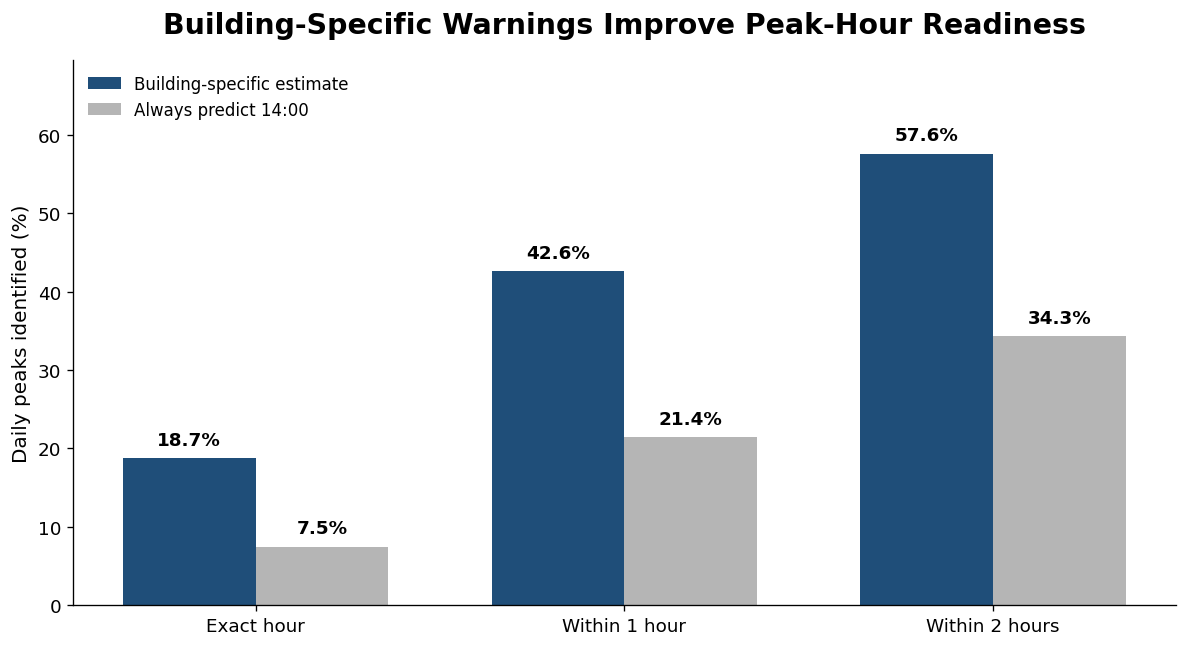

In [8]:
metric_labels = ["Exact hour", "Within 1 hour", "Within 2 hours"]
metric_columns = [
    "exact_peak_accuracy",
    "within_1_hour_accuracy",
    "within_2_hours_accuracy",
]
x_positions = np.arange(len(metric_labels))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=120)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

model_values = model_result[metric_columns].to_numpy(dtype=float) * 100
benchmark_values = benchmark_result[metric_columns].to_numpy(dtype=float) * 100

model_bars = ax.bar(
    x_positions - bar_width / 2,
    model_values,
    width=bar_width,
    color="#1f4e79",
    label="Building-specific estimate",
)
benchmark_bars = ax.bar(
    x_positions + bar_width / 2,
    benchmark_values,
    width=bar_width,
    color="#b5b5b5",
    label="Always predict 14:00",
)

for bars in [model_bars, benchmark_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1.2,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )

ax.set_title(
    "Building-Specific Warnings Improve Peak-Hour Readiness",
    fontsize=17,
    weight="bold",
    pad=16,
)
ax.set_ylabel("Daily peaks identified (%)", fontsize=12)
ax.set_xticks(x_positions, metric_labels)
ax.set_ylim(0, max(model_values.max(), benchmark_values.max()) + 12)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=11)
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
fig.savefig(
    figures_dir / "final_peak_hour_test_comparison.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Interpretation and Limitations

The building-specific result should be compared with both the fixed 2:00 PM
benchmark and the earlier rolling-validation range. A similar final-test result
supports the conclusion that the approach generalizes to a later period.

The prediction is intended as a readiness window rather than a guarantee of one
exact hour. Results come from 2016 ASHRAE buildings and may change as equipment,
occupancy, weather patterns, or operating schedules change. The locked quality
policy also treats changing-reading days as eligible even when more than one hour
shares the daily maximum; tied nonflat maxima remain a limitation for future work.

No further model tuning should be performed against this test result. Any future
improvement should begin a new development cycle with a newly protected test
period.